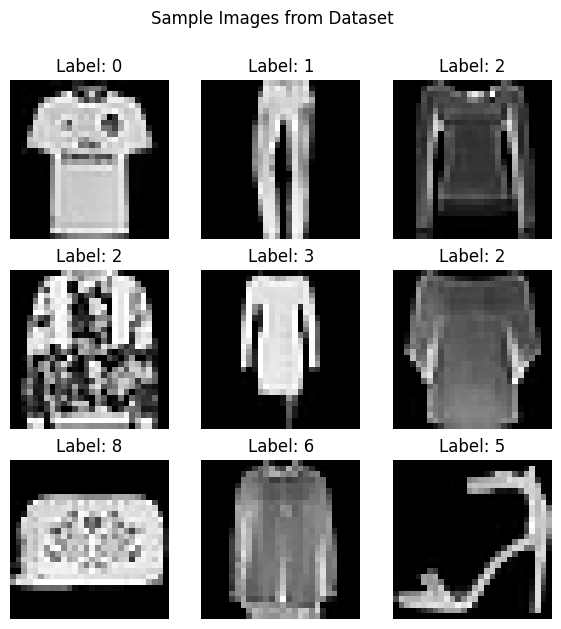

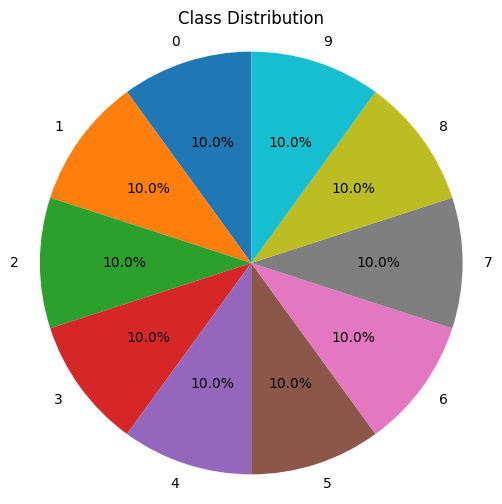

Epoch 1/25, Loss: 102.5497, Train Acc: 76.36%, Test Acc: 86.27%
Epoch 2/25, Loss: 65.9444, Train Acc: 84.59%, Test Acc: 89.23%
Epoch 3/25, Loss: 50.4259, Train Acc: 88.26%, Test Acc: 90.53%
Epoch 4/25, Loss: 42.6633, Train Acc: 89.87%, Test Acc: 92.33%
Epoch 5/25, Loss: 37.5032, Train Acc: 91.28%, Test Acc: 93.25%
Epoch 6/25, Loss: 31.4266, Train Acc: 92.67%, Test Acc: 94.72%
Epoch 7/25, Loss: 26.7979, Train Acc: 93.77%, Test Acc: 95.08%
Epoch 8/25, Loss: 23.7690, Train Acc: 94.18%, Test Acc: 95.22%
Epoch 9/25, Loss: 19.0804, Train Acc: 95.59%, Test Acc: 96.48%
Epoch 10/25, Loss: 16.3850, Train Acc: 96.10%, Test Acc: 96.53%
Epoch 11/25, Loss: 15.2100, Train Acc: 96.46%, Test Acc: 98.54%
Epoch 12/25, Loss: 12.4887, Train Acc: 97.17%, Test Acc: 96.52%
Epoch 13/25, Loss: 11.7500, Train Acc: 97.42%, Test Acc: 96.60%
Epoch 14/25, Loss: 9.2392, Train Acc: 97.99%, Test Acc: 99.39%
Epoch 15/25, Loss: 6.5972, Train Acc: 98.46%, Test Acc: 98.53%
Epoch 16/25, Loss: 7.4211, Train Acc: 98.16%, Test

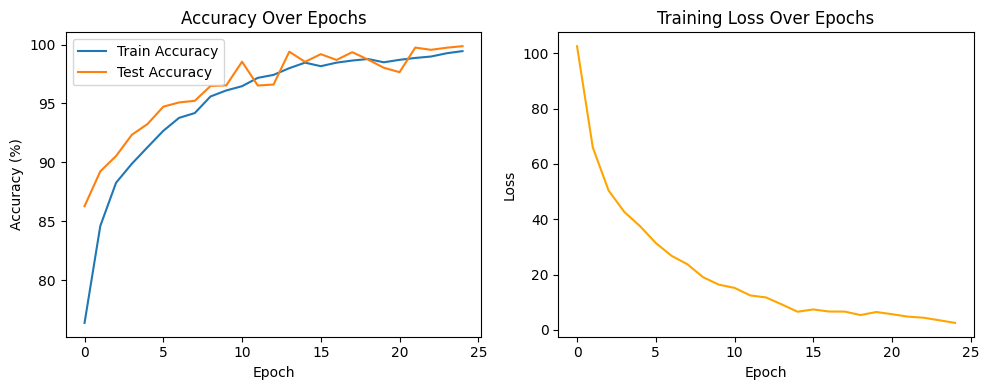

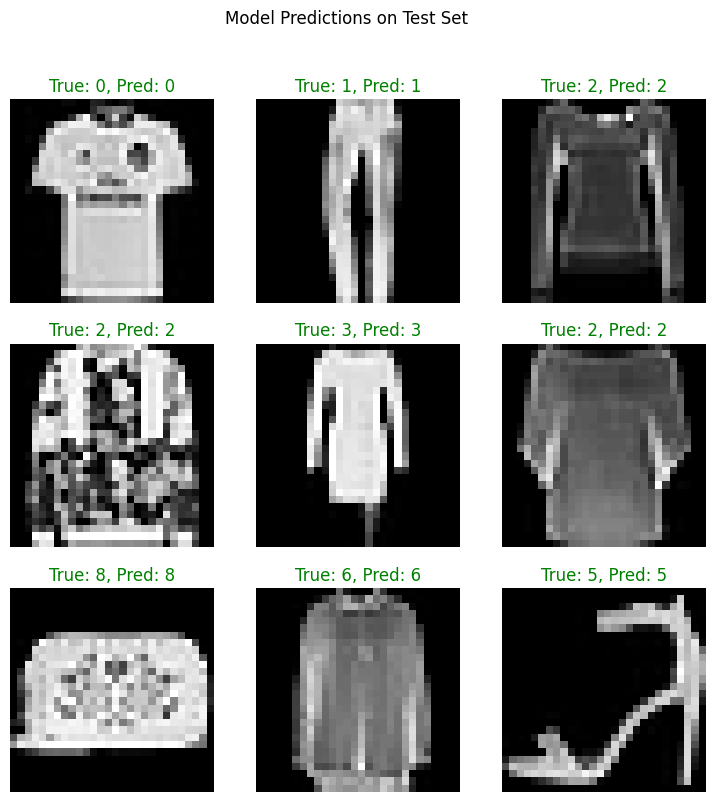


Final Test Accuracy: 99.86%


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Dataset Loader
class MNISTCSVLoader(Dataset):
    def __init__(self, csv_file, transform=None):
        data = pd.read_csv(csv_file)
        self.labels = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)
        self.images = data.iloc[:, 1:].values.reshape(-1, 28, 28).astype("float32")
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# 2. Image Transform
transform = transforms.Compose([
    transforms.Lambda(lambda x: torch.tensor(x).unsqueeze(0)),  # (1, 28, 28)
    transforms.Normalize((0.5,), (0.5,))
])

# 3. Load Data
csv_path = "/kaggle/input/fashion-mnist/fashion-mnist_test.csv"
train_dataset = MNISTCSVLoader(csv_path, transform=transform)
test_dataset = MNISTCSVLoader(csv_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Show sample images
def show_sample_images(dataset, count=9):
    plt.figure(figsize=(7, 7))
    for i in range(count):
        image, label = dataset[i]
        plt.subplot(3, 3, i+1)
        plt.imshow(image.squeeze(0), cmap='gray')
        plt.title(f"Label: {label.item()}")
        plt.axis('off')
    plt.suptitle("Sample Images from Dataset")
    plt.show()

show_sample_images(train_dataset)

# Plot data distribution
def plot_class_distribution(dataset):
    labels = [label.item() for _, label in dataset]
    plt.figure(figsize=(6, 6))
    plt.pie(np.bincount(labels), labels=np.unique(labels), autopct="%1.1f%%", startangle=90)
    plt.title("Class Distribution")
    plt.axis('equal')
    plt.show()

plot_class_distribution(train_dataset)

# 4. CNN Model
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 5. Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

# 6. Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

# 7. Training Loop with Tracking
train_accuracies = []
test_accuracies = []
losses = []

epochs = 25
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    test_acc = evaluate_model(model, test_loader)

    losses.append(total_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

# 8. Accuracy and Loss Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses, color="orange")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

# 9. Predictions Visualization
def show_predictions(model, dataloader, class_names=None, count=9):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(9, 9))

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= count:
                    break
                plt.subplot(3, 3, images_shown + 1)
                img = images[i].cpu().squeeze()
                plt.imshow(img, cmap="gray")
                true_label = labels[i].item()
                pred_label = preds[i].item()
                plt.title(f"True: {true_label}, Pred: {pred_label}", color="green" if true_label == pred_label else "red")
                plt.axis('off')
                images_shown += 1
            if images_shown >= count:
                break
    plt.suptitle("Model Predictions on Test Set")
    plt.show()

show_predictions(model, test_loader)

# Final Accuracy
final_test_acc = evaluate_model(model, test_loader)
print(f"\nFinal Test Accuracy: {final_test_acc:.2f}%")


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 1. Dataset Loader
class MNISTCSVLoader(Dataset):
    def __init__(self, csv_file, transform=None):
        data = pd.read_csv(csv_file)
        self.labels = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)
        self.images = data.iloc[:, 1:].values.reshape(-1, 28, 28).astype("float32")
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# 2. Image Transform
transform = transforms.Compose([
    transforms.Lambda(lambda x: torch.tensor(x).unsqueeze(0)),  # (1, 28, 28)
    transforms.Normalize((0.5,), (0.5,))
])

# 3. Data Loaders
train_dataset = MNISTCSVLoader("/kaggle/input/fashion-mnist/fashion-mnist_test.csv", transform=transform)
test_dataset = MNISTCSVLoader("/kaggle/input/fashion-mnist/fashion-mnist_test.csv", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 4. CNN Model
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # -> (32, 14, 14)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # -> (64, 7, 7)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # -> (128, 3, 3)
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 5. Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

# 6. Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

# 7. Training Loop
epochs = 25
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    test_acc = evaluate_model(model, test_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

# 8. Final Accuracy
final_test_acc = evaluate_model(model, test_loader)
print(f"\nFinal Test Accuracy: {final_test_acc:.2f}%")


Epoch 1/25, Loss: 107.0918, Train Acc: 75.30%, Test Acc: 83.76%
Epoch 2/25, Loss: 63.9815, Train Acc: 85.13%, Test Acc: 85.76%
Epoch 3/25, Loss: 52.1174, Train Acc: 87.81%, Test Acc: 90.61%
Epoch 4/25, Loss: 44.7544, Train Acc: 89.24%, Test Acc: 90.69%
Epoch 5/25, Loss: 37.6120, Train Acc: 91.21%, Test Acc: 93.83%
Epoch 6/25, Loss: 33.0142, Train Acc: 92.06%, Test Acc: 92.68%
Epoch 7/25, Loss: 29.8024, Train Acc: 93.26%, Test Acc: 96.26%
Epoch 8/25, Loss: 25.8225, Train Acc: 93.94%, Test Acc: 96.03%
Epoch 9/25, Loss: 22.6391, Train Acc: 94.79%, Test Acc: 96.11%
Epoch 10/25, Loss: 19.3420, Train Acc: 95.55%, Test Acc: 97.07%
Epoch 11/25, Loss: 16.8634, Train Acc: 96.17%, Test Acc: 97.31%
Epoch 12/25, Loss: 14.2713, Train Acc: 96.68%, Test Acc: 98.51%
Epoch 13/25, Loss: 12.5003, Train Acc: 97.02%, Test Acc: 97.20%
Epoch 14/25, Loss: 9.7988, Train Acc: 97.71%, Test Acc: 97.60%
Epoch 15/25, Loss: 9.4897, Train Acc: 97.94%, Test Acc: 99.06%
Epoch 16/25, Loss: 6.9316, Train Acc: 98.48%, Test

In [4]:
# 9. Save the model
model_path = "fashion_mnist_cnn.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to fashion_mnist_cnn.pth
